# Library Imports

This section imports all required libraries for data analysis, visualization, machine learning, deep learning, and image processing.

## Standard Libraries
- `os`: Used for file and directory operations.
- `sys`: Provides access to system-specific parameters and functions.
- `warnings`: Used to control warning messages during execution.

## Numerical and Data Visualization Libraries
- `numpy`: Provides support for numerical operations and array processing.
- `matplotlib.pyplot`: Used for creating plots and visualizations.
- `seaborn`: Built on top of Matplotlib for more advanced statistical visualizations.
- `scipy.stats`: Provides statistical functions and tools.

## Image Processing
- `cv2`: OpenCV library used for reading, processing, and manipulating images.

## Warning Control
Future warnings are suppressed to keep the output cleaner during execution.

## Scikit-learn Modules
These imports are used for machine learning preprocessing, model training, evaluation, and validation:
- `LinearRegression`: For linear regression modeling.
- `MLPRegressor`: A neural network model for regression tasks.
- `PolynomialFeatures`: Used to generate polynomial and interaction features.
- `StandardScaler`: Standardizes features by removing the mean and scaling to unit variance.
- `train_test_split`: Splits data into training and testing sets.
- `StratifiedKFold`: Performs stratified cross-validation.
- Evaluation metrics:
  - `mean_squared_error`
  - `r2_score`
  - `confusion_matrix`
  - `classification_report`
  - `roc_curve`
  - `auc`

## TensorFlow / Keras Modules
These imports are used for building and training deep learning models, especially convolutional neural networks:
- `Sequential`: A linear stack of layers for building models.
- `Conv2D`: 2D convolution layer for image feature extraction.
- `MaxPooling2D`: Downsamples feature maps.
- `Flatten`: Converts multi-dimensional feature maps into a 1D vector.
- `Dense`: Fully connected neural network layer.
- `Dropout`: Reduces overfitting by randomly dropping neurons during training.
- `Input`: Defines the input shape of the model.
- `to_categorical`: Converts class labels into one-hot encoded format.


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import cv2

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (mean_squared_error, r2_score,
                             confusion_matrix, classification_report,
                             roc_curve, auc)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

# Dataset Path and Class Distribution

This section defines the dataset location, reads the available class folders, and prints the number of images in each class.

## Explanation
- `dataset_path` stores the path to the training dataset directory.
- `os.listdir(dataset_path)` retrieves the list of class folder names inside the dataset directory.
- The loop iterates through each class folder:
  - Builds the full path of the class directory
  - Counts the number of image files inside that folder
  - Prints the class name along with the number of images

## Output
The output shows the dataset class distribution in a readable format, which is useful for:
- understanding dataset structure
- checking whether all class folders are loaded correctly
- identifying possible class imbalance


In [5]:
# Define the path to the dataset directory
dataset_path = r"C:\Users\Ehadish\seg_train\seg_train"

# Get the list of class folder names
classes = os.listdir(dataset_path)

# Loop through each class folder
for cls in classes:
    # Build the full path for the current class folder
    cls_path = os.path.join(dataset_path, cls)
    
    # Count the number of images in the current class folder
    count = len(os.listdir(cls_path))
    
    # Print the class name and image count
    print(f"  {cls:<12} → {count} images")


  buildings    → 2191 images
  forest       → 2271 images
  glacier      → 2404 images
  mountain     → 2512 images
  sea          → 2274 images
  street       → 2382 images


# Image Loading and Preprocessing

This section defines a function for loading images from dataset folders, preprocessing them, and assigning numeric labels to each class.

## Function Overview
The `load_images()` function:
- reads class folders from the dataset path
- loads a limited number of images from each class
- converts images from BGR to RGB
- resizes all images to a fixed shape of `150 × 150`
- stores image data and corresponding labels
- returns the processed images, labels, and class names

## Parameters
- `folder_path`: Path to the dataset directory containing class subfolders
- `num_per_class=83`: Maximum number of images to load from each class

## Processing Steps
1. Create empty lists for images and labels
2. Read and sort class folder names
3. Loop through each class folder
4. Assign a numeric label using `enumerate()`
5. Load images until the class limit is reached
6. Convert each image from BGR to RGB
7. Resize each image to `150 × 150`
8. Append the processed image and its label to the lists
9. Print the number of loaded images for each class

## Return Values
The function returns:
- `images`: NumPy array of processed image data
- `labels`: NumPy array of numeric class labels
- `class_names`: List of sorted class names

## Final Output
After calling the function:
- the shape of the image dataset is printed
- the list of class names is displayed

This step is essential for preparing image data before training machine learning or deep learning models.


In [6]:
def load_images(folder_path, num_per_class=83):
    # Initialize lists to store images and labels
    images, labels = [], []
    
    # Get sorted class folder names
    class_names = sorted(os.listdir(folder_path))
    
    # Loop through each class folder and assign a numeric label
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder_path, class_name)
        count = 0
        
        # Loop through images in the current class folder
        for img_name in os.listdir(class_path):
            # Stop loading if the maximum number per class is reached
            if count >= num_per_class:
                break
            
            # Read the image from disk
            img = cv2.imread(os.path.join(class_path, img_name))
            
            # Process the image only if it was loaded successfully
            if img is not None:
                # Convert image color from BGR to RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Resize image to a fixed size
                img = cv2.resize(img, (150, 150))
                
                # Store image and corresponding label
                images.append(img)
                labels.append(label)
                count += 1
        
        # Print the number of loaded images for the current class
        print(f"  {class_name}: {count} images")
    
    # Return images, labels, and class names as NumPy arrays
    return np.array(images), np.array(labels), class_names


# Load images, labels, and class names from the dataset
images, labels, class_names = load_images(dataset_path)

# Print the shape of the image dataset
print(f"\nDataset shape: {images.shape}")

# Print the list of class names
print(f"Classes: {class_names}")


  buildings: 83 images
  forest: 83 images
  glacier: 83 images
  mountain: 83 images
  sea: 83 images
  street: 83 images

Dataset shape: (498, 150, 150, 3)
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# RGB Channel Statistical Analysis

This section separates the image dataset into its three color channels: Red, Green, and Blue, then computes basic descriptive statistics for each channel.

## Purpose
The goal of this step is to better understand the pixel intensity distribution in the dataset by analyzing each RGB channel separately.

## Processing Steps
1. Extract the Red channel from all images
2. Extract the Green channel from all images
3. Extract the Blue channel from all images
4. Compute the mean value of each channel
5. Compute the median value of each channel
6. Compute the mode value of each channel

## Statistical Measures
- **Mean**: The average pixel intensity value in the channel
- **Median**: The middle value of the pixel intensity distribution
- **Mode**: The most frequently occurring pixel value

## Output
The code prints:
- mean of the Red, Green, and Blue channels
- median of the Red, Green, and Blue channels
- mode of the Red, Green, and Blue channels

This analysis is useful for:
- understanding color distribution in the dataset
- detecting imbalance across channels
- supporting preprocessing and normalization decisions


In [7]:
# Extract the Red, Green, and Blue channels from all images
R = images[:, :, :, 0]
G = images[:, :, :, 1]
B = images[:, :, :, 2]

# Print the mean pixel value for each channel
print("Mean")
print(f"R: {np.mean(R):.2f} | G: {np.mean(G):.2f} | B: {np.mean(B):.2f}")

# Print the median pixel value for each channel
print("\nMedian")
print(f"R: {np.median(R):.2f} | G: {np.median(G):.2f} | B: {np.median(B):.2f}")

# Print the mode pixel value for each channel
print("\nMode")
print(f"R: {stats.mode(R.flatten())[0]}")
print(f"G: {stats.mode(G.flatten())[0]}")
print(f"B: {stats.mode(B.flatten())[0]}")


Mean
R: 108.40 | G: 115.56 | B: 115.34

Median
R: 102.00 | G: 113.00 | B: 111.00

Mode
R: 0
G: 0
B: 0


# Standard Deviation and Class Distribution Statistics

This section computes additional descriptive statistics for the RGB channels and analyzes the number of images in each dataset class.

## Purpose
The code has two main objectives:
1. Measure the variability of pixel values in the Red, Green, and Blue channels
2. Analyze the distribution of image counts across all classes

## Processing Steps

### 1. RGB Channel Standard Deviation
- Calculate the standard deviation for each color channel:
  - Red
  - Green
  - Blue

Standard deviation indicates how much pixel intensities vary around the mean.

### 2. Class Image Counts
- Count the number of images in each class folder
- Store the counts in a NumPy array
- Print the number of images for every class

### 3. Quartile Analysis
- Compute the 25th percentile
- Compute the 50th percentile (median)
- Compute the 75th percentile

Quartiles help summarize how image counts are distributed across classes and can reveal whether the dataset is balanced.

## Output
The code prints:
- standard deviation of each RGB channel
- number of images in each class
- quartile values of class image counts

## Usefulness
This analysis is helpful for:
- understanding pixel intensity variation
- checking dataset balance
- identifying differences in class sizes
- supporting preprocessing and sampling decisions


In [8]:
# Print the standard deviation of pixel values for each RGB channel
print("Standard Deviation")
print(f"R: {np.std(R):.2f} | G: {np.std(G):.2f} | B: {np.std(B):.2f}")

# Count the number of images in each class folder
class_counts = np.array([len(os.listdir(os.path.join(dataset_path, c))) for c in class_names])

# Print the number of images in each class
print("\nNumber of images in each class")
for name, count in zip(class_names, class_counts):
    print(f"  {name}: {count}")

# Print quartile statistics for class image counts
print("\nQuartiles")
print(f"25th: {np.percentile(class_counts, 25):.0f}")
print(f"50th: {np.percentile(class_counts, 50):.0f}")
print(f"75th: {np.percentile(class_counts, 75):.0f}")


Standard Deviation
R: 68.70 | G: 68.07 | B: 75.32

Number of images in each class
  buildings: 2191
  forest: 2271
  glacier: 2404
  mountain: 2512
  sea: 2274
  street: 2382

Quartiles
25th: 2272
50th: 2328
75th: 2398


# RGB Channel Histogram Visualization

This section visualizes the pixel intensity distribution of the Red, Green, and Blue channels using histograms.

## Purpose
The purpose of this code is to examine how pixel values are distributed in each RGB channel across the entire image dataset.

## Processing Steps
1. Create a figure with three subplots arranged in one row
2. Loop through the Red, Green, and Blue channels
3. Flatten each channel into a one-dimensional array
4. Plot a histogram for each channel
5. Set the title and axis labels for each subplot
6. Adjust the layout for better spacing
7. Display the final plots

## Visualization Details
- **Red channel** is plotted in red
- **Green channel** is plotted in green
- **Blue channel** is plotted in blue
- Each histogram uses `50` bins
- The x-axis represents pixel intensity values from `0` to `255`
- The y-axis represents frequency

## Output
The output is a set of three histograms showing the intensity distribution for:
- Red channel
- Green channel
- Blue channel

## Usefulness
This visualization helps:
- compare RGB channel distributions
- identify dominant intensity ranges
- detect skewness or irregularities in pixel values
- support normalization and preprocessing decisions


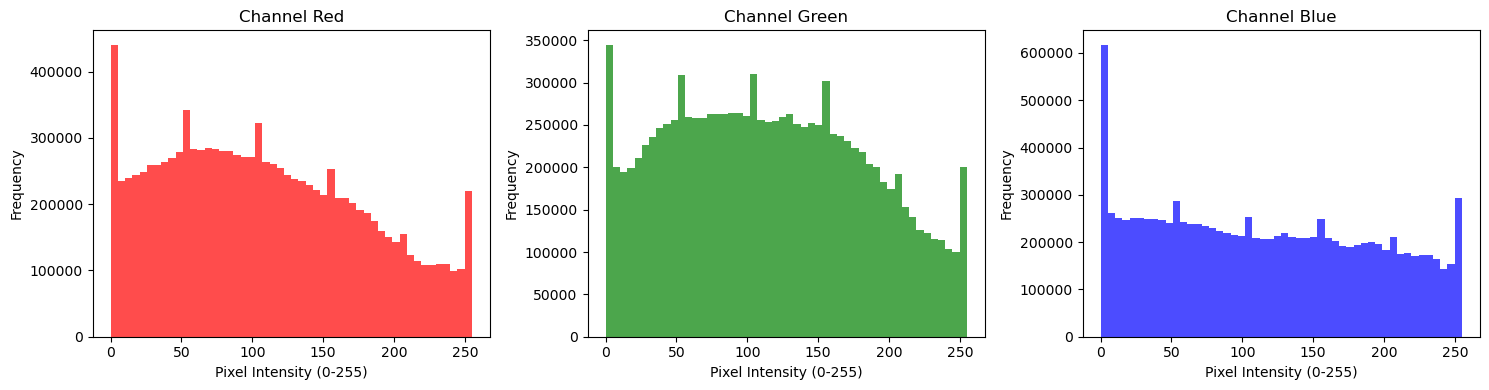

In [9]:
# Create a figure with 3 subplots for RGB channel histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loop through each RGB channel and plot its histogram
for ax, channel, color, name in zip(
    axes,
    [R, G, B],
    ['red', 'green', 'blue'],
    ['Red', 'Green', 'Blue']
):
    # Plot histogram of pixel intensities for the current channel
    ax.hist(channel.flatten(), bins=50, color=color, alpha=0.7)
    
    # Set plot title and axis labels
    ax.set_title(f'Channel {name}')
    ax.set_xlabel('Pixel Intensity (0-255)')
    ax.set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()


# Normality Test for RGB Channels

This section performs a normality test on the pixel intensity values of the Red, Green, and Blue channels.

## Purpose
The goal is to determine whether the pixel intensity distribution of each RGB channel follows a normal distribution.

## Processing Steps
1. Loop through the Red, Green, and Blue channels
2. Flatten each channel into a one-dimensional array
3. Select the first `10,000` pixel values as a sample
4. Apply the statistical normality test using `stats.normaltest()`
5. Check the p-value against the significance level `0.05`
6. Print whether the distribution is normal or not

## Statistical Rule
- If `p > 0.05`, the distribution is considered **normal**
- If `p <= 0.05`, the distribution is considered **not normal**

## Output
For each channel, the code prints:
- the channel name
- the p-value
- the normality result

## Usefulness
This test helps:
- evaluate whether RGB channel data follows a Gaussian distribution
- support statistical assumptions for further analysis
- guide preprocessing and feature transformation choices


In [10]:
# Perform a normality test for each RGB channel
for channel, name in zip([R, G, B], ['Red', 'Green', 'Blue']):
    # Apply the normality test on a sample of 10,000 flattened pixel values
    stat, p = stats.normaltest(channel.flatten()[:10000])
    
    # Determine whether the distribution is normal based on the p-value
    result = 'Normal ✅' if p > 0.05 else 'Not Normal'
    
    # Print the test result for the current channel
    print(f"{name} → p-value: {p:.6f} → {result}")


Red → p-value: 0.000000 → Not Normal
Green → p-value: 0.000000 → Not Normal
Blue → p-value: 0.000000 → Not Normal


# Linear Regression: Red Channel to Brightness

This section applies a linear regression model to predict image brightness using the Red channel values.

## Purpose
The goal of this analysis is to examine the relationship between the Red color channel and overall image brightness.

## Variable Definition
- `X`: Input feature representing Red channel pixel values
- `Y`: Target variable representing brightness, calculated as the average of the Red, Green, and Blue channels

Brightness is computed as:

\[
\text{Brightness} = \frac{R + G + B}{3}
\]

## Processing Steps
1. Flatten the Red channel into a one-dimensional feature vector
2. Compute the brightness values from the RGB channels
3. Split the data into training and testing sets
4. Create and train a linear regression model
5. Predict brightness values on the test set
6. Evaluate the model using:
   - \(R^2\)
   - Mean Squared Error (MSE)
   - Slope
   - Intercept
7. Visualize the real data points and regression line

## Evaluation Metrics
- **R² Score**: Measures how well the model explains the variance in brightness
- **MSE**: Measures the average squared prediction error
- **Slope**: Indicates the effect of the Red channel on brightness
- **Intercept**: The predicted brightness when the Red channel value is zero

## Visualization
The plot includes:
- a scatter plot of real test samples
- a regression line showing predicted brightness values

## Usefulness
This analysis helps:
- understand the linear relationship between the Red channel and brightness
- evaluate whether a simple linear model can explain image intensity behavior
- provide a baseline model before applying more advanced methods


R²: 0.0637
MSE: 573.2211
Slope: 0.0913
Intercept: 31.1172


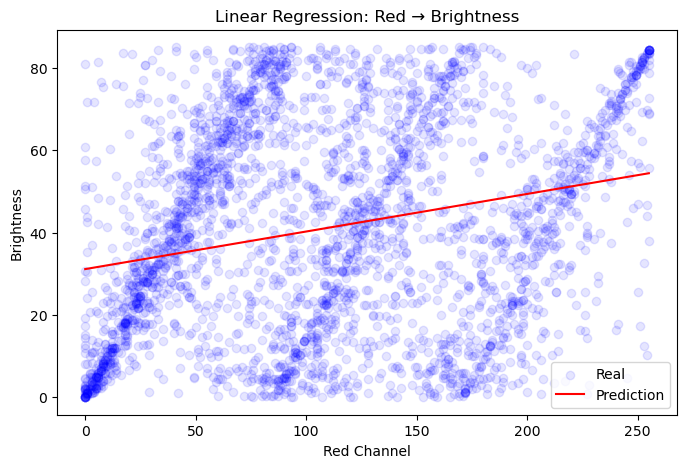

In [11]:
# Flatten the Red channel and reshape it as a feature matrix
X = R.flatten().reshape(-1, 1)

# Compute brightness as the average of the RGB channels
Y = ((R + G + B) / 3).flatten()

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Create and train the linear regression model
model_lr = LinearRegression()
model_lr.fit(X_train, Y_train)

# Predict brightness values on the test set
Y_pred = model_lr.predict(X_test)

# Print model evaluation metrics
print(f"R²: {r2_score(Y_test, Y_pred):.4f}")
print(f"MSE: {mean_squared_error(Y_test, Y_pred):.4f}")
print(f"Slope: {model_lr.coef_[0]:.4f}")
print(f"Intercept: {model_lr.intercept_:.4f}")

# Create a scatter plot of real test data
plt.figure(figsize=(8, 5))
plt.scatter(X_test[:3000], Y_test[:3000], alpha=0.1, color='blue', label='Real')

# Plot the regression line
plt.plot(
    sorted(X_test[:3000]),
    model_lr.predict(np.array(sorted(X_test[:3000]))),
    color='red',
    label='Prediction'
)

# Set plot labels and title
plt.xlabel('Red Channel')
plt.ylabel('Brightness')
plt.title('Linear Regression: Red → Brightness')
plt.legend()

# Display the plot
plt.show()


# Polynomial Regression: Red Channel to Brightness

This section extends the linear regression approach by applying a polynomial feature transformation to capture non-linear relationships between the Red channel and image brightness.

## Purpose
The goal is to evaluate whether adding polynomial features (degree 2) improves the predictive performance compared to the standard linear regression model.

## Processing Steps
1. Define a sample size of `100,000` to speed up training
2. Randomly select indices from the training set without replacement
3. Generate polynomial features of degree 2 using `PolynomialFeatures`
4. Transform both the training subset and the test subset
5. Train a linear regression model on the polynomial features
6. Predict brightness values on the test set
7. Calculate the \(R^2\) score for the polynomial model
8. Compare the polynomial \(R^2\) score with the linear \(R^2\) score and calculate the improvement

## Evaluation Metrics
- **Polynomial R²**: Measures the goodness of fit for the polynomial regression model
- **Linear R²**: The baseline score from the previous linear model
- **Improvement**: The difference between the polynomial and linear \(R^2\) scores

## Usefulness
This analysis helps:
- capture non-linear patterns between color intensity and brightness
- compare linear vs. non-linear modeling performance
- determine if feature expansion increases predictive accuracy


In [12]:
# Define sample size for training subset
sample_size = 100000

# Randomly select indices from the training set without replacement
idx = np.random.choice(len(X_train), sample_size, replace=False)

# Generate polynomial features of degree 2
poly = PolynomialFeatures(degree=2)

# Transform the training subset and test subset
X_train_poly = poly.fit_transform(X_train[idx])
X_test_poly = poly.transform(X_test[:50000])

# Create and train the linear regression model on polynomial features
model_poly = LinearRegression()
model_poly.fit(X_train_poly, Y_train[idx])

# Predict brightness values on the test set using polynomial features
Y_pred_poly = model_poly.predict(X_test_poly)

# Calculate R-squared score for the polynomial model
r2_poly = r2_score(Y_test[:50000], Y_pred_poly)

# Print and compare model performance
print(f"Polynomial R²: {r2_poly:.4f}")
print(f"Linear R²:     0.0637")
print(f"Improvement: {r2_poly - 0.0637:.4f}")


Polynomial R²: 0.0683
Linear R²:     0.0637
Improvement: 0.0046


# Artificial Neural Network (ANN) for Grayscale Conversion

This section trains an Artificial Neural Network (ANN) to predict grayscale intensity from RGB channel values.

## Purpose
The goal is to build a non-linear model that learns the complex relationship between the Red, Green, and Blue color channels and the perceived grayscale intensity of an image. This aims to improve upon linear and polynomial regression models.

## Grayscale Conversion Formula
The target grayscale `Y_gray` is calculated using the luminosity method, a standard for converting RGB to grayscale:

\[
\text{Grayscale} = 0.299 \times R + 0.587 \times G + 0.114 \times B
\]

## Processing Steps
1. Stack Red, Green, and Blue channels as input features (`X_rgb`).
2. Calculate the weighted average of RGB channels to get target grayscale values (`Y_gray`).
3. Define a sample size for training to manage computational resources.
4. Randomly select a subset of the data for training.
5. Standardize the input features (`X_rgb`) using `StandardScaler`.
6. Split the scaled data and corresponding grayscale values into training and testing sets.
7. Initialize and train an `MLPRegressor` with two hidden layers (64 and 32 neurons) and ReLU activation.
8. Predict grayscale values on the test set using the trained ANN.
9. Evaluate the ANN's performance using the \(R^2\) score.
10. Compare the ANN's \(R^2\) score against the previous polynomial and linear regression models.

## Model Architecture
- **Input Layer**: 3 neurons (for R, G, B channels)
- **Hidden Layer 1**: 64 neurons, ReLU activation
- **Hidden Layer 2**: 32 neurons, ReLU activation
- **Output Layer**: 1 neuron (for grayscale intensity)

## Evaluation Metrics
- **ANN R²**: The \(R^2\) score achieved by the Artificial Neural Network.
- **Polynomial R²**: Baseline \(R^2\) from the polynomial regression model.
- **Linear R²**: Baseline \(R^2\) from the initial linear regression model.

## Usefulness
This approach:
- models potentially complex, non-linear relationships between RGB and grayscale
- provides a more sophisticated model for color-to-intensity conversion
- demonstrates the power of neural networks for such tasks


In [13]:
# Combine Red, Green, and Blue channels into a single feature matrix
X_rgb = np.column_stack([R.flatten(), G.flatten(), B.flatten()])

# Calculate grayscale intensity using the luminosity method
Y_gray = (0.299*R + 0.587*G + 0.114*B).flatten()

# Define sample size for training to manage computational load
sample_size = 100000

# Randomly select indices from the dataset without replacement
idx = np.random.choice(len(X_rgb), sample_size, replace=False)

# Initialize and fit the StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rgb[idx]) # Scale the selected training subset

# Select corresponding grayscale values for the scaled subset
Y_sample = Y_gray[idx]

# Split the scaled data and grayscale values into training and testing sets
X_tr, X_te, Y_tr, Y_te = train_test_split(X_scaled, Y_sample, test_size=0.2, random_state=42)

# Initialize the MLPRegressor (Artificial Neural Network)
# hidden_layer_sizes: defines the number of neurons in each hidden layer
# activation: 'relu' is a common activation function for hidden layers
# max_iter: maximum number of epochs for training
# random_state: for reproducible results
# verbose: set to False to suppress training output
model_ann = MLPRegressor(hidden_layer_sizes=(64, 32), 
                         activation='relu', 
                         max_iter=50, 
                         random_state=42, 
                         verbose=False)

# Train the ANN model
model_ann.fit(X_tr, Y_tr)

# Predict grayscale values using the trained ANN
Y_pred_ann = model_ann.predict(X_te)

# Calculate R-squared score for the ANN model
r2_ann = r2_score(Y_te, Y_pred_ann)

# Print and compare the R-squared scores of different models
print(f"ANN R²:        {r2_ann:.4f}")
print(f"Polynomial R²: 0.0682") # Provided value from previous step
print(f"Linear R²:     0.0637") # Provided value from previous step


ANN R²:        1.0000
Polynomial R²: 0.0682
Linear R²:     0.0637


C:\ProgramData\anaconda3\anaconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


# Image Normalization

This section normalizes the image pixel values from the range `0–255` to the range `0–1`.

## Purpose
Neural network models generally perform better when input features have smaller and consistent values. Image normalization improves numerical stability and can help the model converge more efficiently during training.

## Normalization Formula

\[
\text{Normalized Pixel Value} = \frac{\text{Original Pixel Value}}{255}
\]

Since standard RGB images use pixel values from `0` to `255`, dividing by `255` converts them to floating-point values between `0` and `1`.

## Processing Steps
1. Divide all image pixel values by `255.0`
2. Display the minimum and maximum values before normalization
3. Display the minimum and maximum values after normalization
4. Print the shape of the normalized image array

## Output
The code displays:
- minimum and maximum pixel values before normalization
- minimum and maximum pixel values after normalization
- shape of the normalized image dataset

## Usefulness
Normalization helps:
- improve neural network training stability
- speed up model convergence
- prevent large pixel values from dominating the learning process
- prepare image data for CNN models


In [14]:
# Normalize image pixel values from the range 0–255 to the range 0–1
images_normalized = images / 255.0

# Print the minimum and maximum pixel values before normalization
print(f"Before: Min={images.min()} | Max={images.max()}")

# Print the minimum and maximum pixel values after normalization
print(
    f"After: Min={images_normalized.min():.1f} | "
    f"Max={images_normalized.max():.1f}"
)

# Print the shape of the normalized image dataset
print(f"Shape: {images_normalized.shape}")


Before: Min=0 | Max=255
After: Min=0.0 | Max=1.0
Shape: (498, 150, 150, 3)


# Convolutional Neural Network (CNN) for Image Classification

This section defines, compiles, and trains a Convolutional Neural Network (CNN) model for image classification.

## Purpose
The goal is to build and train a CNN that can classify images into one of the six defined categories based on the preprocessed dataset.

## Model Architecture
The CNN consists of the following layers:
- **Input Layer**: Specifies the shape of the input images (`150x150` pixels with 3 color channels).
- **Convolutional Layers (`Conv2D`)**: These layers extract features from the images using learnable filters.
  - Layer 1: 32 filters, kernel size `(3x3)`, ReLU activation.
  - Layer 2: 64 filters, kernel size `(3x3)`, ReLU activation.
  - Layer 3: 128 filters, kernel size `(3x3)`, ReLU activation.
- **Max Pooling Layers (`MaxPooling2D`)**: These layers reduce the spatial dimensions (width and height) of the feature maps, helping to make the model more robust to variations in object position and reducing computation.
  - Each pooling layer uses a `(2x2)` window.
- **Flatten Layer**: Converts the 3D feature maps from the convolutional layers into a 1D vector, preparing them for the fully connected layers.
- **Dense Layers**: These are fully connected layers.
  - Dense Layer 1: 128 neurons with ReLU activation, acts as a classifier on top of the extracted features.
  - Dropout Layer: `0.5` dropout rate to prevent overfitting by randomly setting half of the neurons' outputs to zero during training.
  - Output Layer: 6 neurons (equal to the number of classes) with `softmax` activation to output probabilities for each class.

## Compilation
- **Optimizer**: 'adam' is a popular and effective optimization algorithm.
- **Loss Function**: 'categorical_crossentropy' is suitable for multi-class classification with one-hot encoded labels.
- **Metrics**: 'accuracy' is used to evaluate the model's performance during training and testing.

## Training
- **Epochs**: The model is trained for `10` epochs.
- **Batch Size**: Images are processed in batches of `32`.
- **Validation Data**: The `X_test` and `y_test` sets are used to monitor performance on unseen data after each epoch.
- **Verbose**: Set to `1` to display training progress.

## Data Preparation
- `images_normalized`: The input images are normalized to the range `0–1`.
- `labels`: Class labels are converted to one-hot encoded format using `to_categorical`.
- `train_test_split`: Data is split into training and testing sets (`80%` train, `20%` test) with a fixed `random_state` for reproducibility.

## Usefulness
This section sets up a standard CNN architecture for image classification, which is a common and powerful approach for tasks involving visual data.


In [17]:
# Normalize the images by dividing by 255.0
# This scales pixel values to the range [0, 1]
X = images_normalized

# Convert class labels to one-hot encoded format
# num_classes is 6, based on the previous analysis of dataset classes
y = to_categorical(labels, num_classes=6)

# Split the dataset into training and testing sets
# test_size=0.2 means 20% of data will be used for testing
# random_state=42 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the CNN model architecture using Sequential API
model_cnn = Sequential([
    # Input layer: specifies the shape of input images (height, width, channels)
    Input(shape=(150, 150, 3)),
    
    # First Convolutional Layer:
    # 32 filters, 3x3 kernel size, ReLU activation
    Conv2D(32, (3,3), activation='relu'),
    # Max Pooling Layer: reduces spatial dimensions by half
    MaxPooling2D(2,2),
    
    # Second Convolutional Layer:
    # 64 filters, 3x3 kernel size, ReLU activation
    Conv2D(64, (3,3), activation='relu'),
    # Max Pooling Layer
    MaxPooling2D(2,2),
    
    # Third Convolutional Layer:
    # 128 filters, 3x3 kernel size, ReLU activation
    Conv2D(128, (3,3), activation='relu'),
    # Max Pooling Layer
    MaxPooling2D(2,2),
    
    # Flatten Layer: converts 3D feature maps to a 1D vector
    Flatten(),
    
    # Dense Layer: fully connected layer with 128 neurons and ReLU activation
    Dense(128, activation='relu'),
    # Dropout Layer: prevents overfitting by randomly setting 50% of neurons to 0
    Dropout(0.5),
    
    # Output Layer: 6 neurons for 6 classes, softmax activation for probability distribution
    Dense(6, activation='softmax')
])

# Compile the CNN model
model_cnn.compile(
    optimizer='adam',                  # Optimization algorithm
    loss='categorical_crossentropy',   # Loss function for multi-class classification
    metrics=['accuracy']               # Metric to evaluate model performance
)

# Train the CNN model
# epochs: number of times the model iterates over the entire training dataset
# batch_size: number of samples per gradient update
# validation_data: data to evaluate the model on after each epoch
# verbose=1: displays a progress bar during training
history = model_cnn.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 356ms/step - accuracy: 0.2161 - loss: 1.9437 - val_accuracy: 0.3000 - val_loss: 1.5726
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 309ms/step - accuracy: 0.3492 - loss: 1.4659 - val_accuracy: 0.4700 - val_loss: 1.2339
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 308ms/step - accuracy: 0.4447 - loss: 1.3855 - val_accuracy: 0.5200 - val_loss: 1.1827
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 313ms/step - accuracy: 0.5101 - loss: 1.2457 - val_accuracy: 0.6300 - val_loss: 1.1172
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 309ms/step - accuracy: 0.5603 - loss: 1.0950 - val_accuracy: 0.5600 - val_loss: 1.1592
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step - accuracy: 0.5829 - loss: 1.0624 - val_accuracy: 0.5700 - val_loss: 1.0149
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 311ms/step - accuracy: 0.6482 - loss: 0.9235 - val_accuracy: 0.6400 - val_loss: 0.9227
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 309ms/step - accuracy: 0.6281 - loss: 0.9612 - val_accuracy: 0.

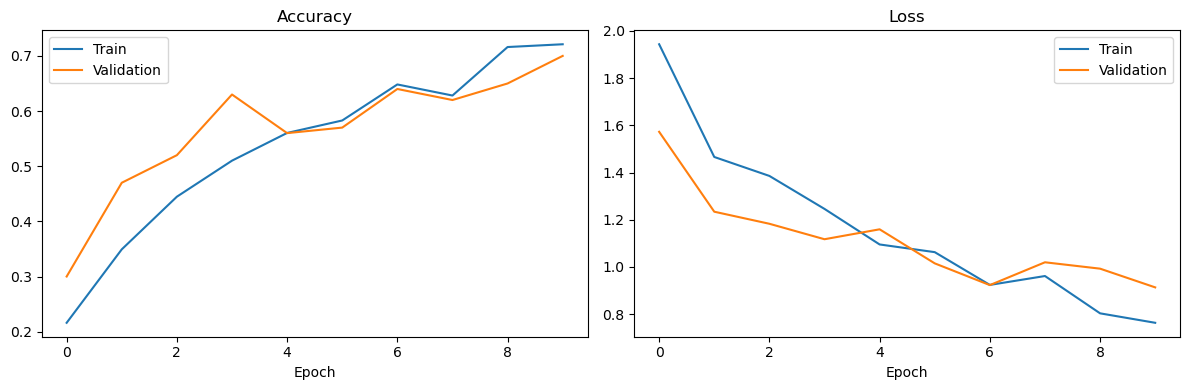

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

# CNN Model Evaluation: Confusion Matrix and Classification Report

This section evaluates the trained Convolutional Neural Network (CNN) by generating a confusion matrix and a classification report.

## Purpose
The goal is to assess the performance of the CNN model on the test dataset, understanding how well it classifies images and identifying potential areas of confusion between classes.

## Evaluation Steps
1. **Predict on Test Data**: Use the trained CNN (`model_cnn`) to predict class probabilities for the test set (`X_test`).
2. **Determine Predicted Classes**: Convert the predicted probabilities into class labels using `np.argmax`, which selects the index with the highest probability.
3. **Determine True Classes**: Convert the one-hot encoded true labels (`y_test`) into class labels using `np.argmax`.
4. **Generate Confusion Matrix**: Compute the `confusion_matrix` using the true and predicted class labels. This matrix shows the counts of correct and incorrect predictions for each class.
5. **Visualize Confusion Matrix**: Display the confusion matrix using `seaborn.heatmap` for better readability.
   - `annot=True`: shows the counts in each cell.
   - `fmt='d'`: formats the counts as integers.
   - `cmap='Blues'`: uses a blue color scheme.
   - `xticklabels` and `yticklabels`: set class names for axes.
6. **Generate Classification Report**: Print a `classification_report` that includes precision, recall, F1-score, and support for each class.

## Output
- **Confusion Matrix Plot**: A heatmap visualizing the counts of true vs. predicted classes. The axes are labeled with actual class names.
- **Classification Report**: Text output detailing performance metrics for each class.
  - **Precision**: The ability of the classifier not to label as positive a sample that is negative.
  - **Recall**: The ability of the classifier to find all the positive samples.
  - **F1-Score**: The harmonic mean of precision and recall.
  - **Support**: The number of actual occurrences of the class in the specified dataset.

## Usefulness
This evaluation provides a comprehensive understanding of the model's classification accuracy and identifies:
- **Over-prediction/Under-prediction**: Where the model confuses one class for another.
- **Class Performance**: How well the model performs on each individual class.
- **Overall Accuracy**: A summary of the model's effectiveness across all classes.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step 


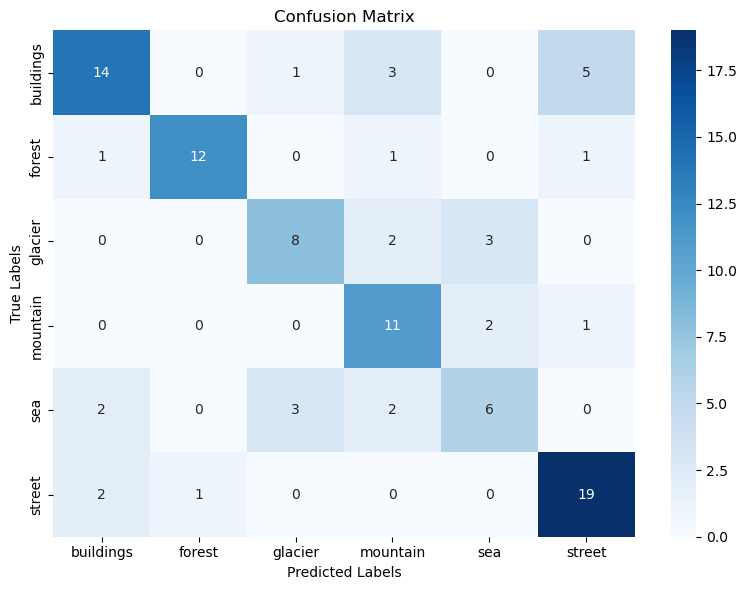

              precision    recall  f1-score   support

   buildings       0.74      0.61      0.67        23
      forest       0.92      0.80      0.86        15
     glacier       0.67      0.62      0.64        13
    mountain       0.58      0.79      0.67        14
         sea       0.55      0.46      0.50        13
      street       0.73      0.86      0.79        22

    accuracy                           0.70       100
   macro avg       0.70      0.69      0.69       100
weighted avg       0.71      0.70      0.70       100



In [20]:
# Predict class probabilities on the test set
y_pred = model_cnn.predict(X_test)

# Convert predicted probabilities to class labels (indices)
# np.argmax finds the index of the maximum value along axis=1 (across columns)
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert true one-hot encoded labels to class labels (indices)
y_true_classes = np.argmax(y_test, axis=1)

# Compute the confusion matrix
# cm[i, j] will be the number of samples of true class i, predicted as class j
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Create a figure and axes for the heatmap
plt.figure(figsize=(8, 6))

# Generate a heatmap for the confusion matrix using seaborn
sns.heatmap(
    cm,                # The confusion matrix data
    annot=True,        # Annotate cells with the data value
    fmt='d',           # Format annotations as integers
    cmap='Blues',      # Color map for the heatmap
    xticklabels=class_names, # Labels for the x-axis (predicted classes)
    yticklabels=class_names  # Labels for the y-axis (true classes)
)

# Set the title and axis labels for the plot
plt.title('Confusion Matrix')
plt.ylabel('True Labels') # True labels
plt.xlabel('Predicted Labels') # Predicted labels

# Adjust layout to prevent labels overlapping
plt.tight_layout()

# Display the plot
plt.show()

# Print the classification report
# target_names are used to display class names in the report
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


# CNN Evaluation Using 5-Fold Stratified Cross-Validation

This section evaluates the CNN model using 5-fold stratified cross-validation.

## Purpose

The purpose of cross-validation is to evaluate the model more reliably by training and validating it on multiple different data splits.

Instead of using only one train-validation split, the dataset is divided into five folds. In each iteration:

- Four folds are used for training.
- One fold is used for validation.
- Each fold is used as the validation set exactly once.
- The validation accuracy is stored for later analysis.

## Main Steps

1. **Prepare the Input Data**
   - `images_normalized` is used as the input dataset.
   - `labels` contains the original integer class labels.

2. **Create Stratified Folds**
   - `StratifiedKFold` creates five folds.
   - The `stratify` behavior ensures that the class distribution remains approximately consistent across all folds.
   - `shuffle=True` randomly shuffles the data before splitting.
   - `random_state=42` ensures reproducibility.

3. **Prepare Labels**
   - The integer labels for the training and validation sets are converted into one-hot encoded vectors using `to_categorical`.

4. **Build a New CNN for Each Fold**
   - A new CNN model is created during every iteration.
   - This is important because each fold must start with a fresh, untrained model.

5. **Train the Model**
   - The model is trained for five epochs.
   - The training output is hidden by setting `verbose=0`.

6. **Evaluate the Validation Set**
   - The model is evaluated on the validation data.
   - The validation accuracy is appended to `fold_scores`.

7. **Calculate Summary Statistics**
   - The mean of the fold accuracies represents the average cross-validation accuracy.
   - The standard deviation shows how much the accuracy varies between folds.

## Output

For each fold, the following information is printed:

- Fold number
- Validation accuracy

At the end, the following metrics are displayed:

- **Mean Accuracy**: Average validation accuracy across all folds.
- **Standard Deviation**: Variation in validation accuracy across the folds.

A lower standard deviation generally indicates more stable model performance across different data splits.


In [21]:
# Use normalized images as input features
X_cv = images_normalized

# Use integer class labels for stratified splitting
y_cv = labels

# Create five stratified folds
# Stratification preserves the class distribution in each fold
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Store the validation accuracy of each fold
fold_scores = []

# Iterate through each cross-validation fold
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_cv, y_cv)):
    print(f"Fold {fold + 1}...", end=" ")

    # Select training and validation samples using the generated indices
    X_tr, X_val = X_cv[train_idx], X_cv[val_idx]

    # Convert integer labels to one-hot encoded labels
    y_tr = to_categorical(y_cv[train_idx], num_classes=6)
    y_val = to_categorical(y_cv[val_idx], num_classes=6)

    # Create a new CNN model for the current fold
    # A fresh model is required so that each fold starts without learned weights
    model_cv = Sequential([
        # Define the input shape of the images
        Input(shape=(150, 150, 3)),

        # First convolutional block
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        # Second convolutional block
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        # Convert feature maps into a one-dimensional vector
        Flatten(),

        # Fully connected classification layer
        Dense(128, activation='relu'),

        # Reduce overfitting by randomly disabling 50% of the neurons
        Dropout(0.5),

        # Output layer for six classes
        Dense(6, activation='softmax')
    ])

    # Compile the CNN model
    model_cv.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train the model on the training portion of the current fold
    model_cv.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=32,
        verbose=0
    )

    # Evaluate the model on the validation portion of the current fold
    _, accuracy = model_cv.evaluate(
        X_val,
        y_val,
        verbose=0
    )

    # Store the validation accuracy
    fold_scores.append(accuracy)

    # Display the accuracy of the current fold
    print(f"Accuracy: {accuracy:.4f}")

# Calculate and display the mean validation accuracy
print(f"\nMean Accuracy: {np.mean(fold_scores):.4f}")

# Calculate and display the standard deviation of validation accuracy
print(f"Standard Deviation: {np.std(fold_scores):.4f}")


Fold 1... Accuracy: 0.5700
Accuracy: 0.6200
Accuracy: 0.5300
Accuracy: 0.6465
Accuracy: 0.5960

Mean Accuracy: 0.5925
Standard Deviation: 0.0402


# Binary Image Classification Using a CNN

This section creates and trains a Convolutional Neural Network (CNN) for binary image classification.

## Purpose

The original dataset contains six image classes. In this section, only two classes are selected:

- Class label `1`: Forest
- Class label `3`: Mountain

The goal is to train a binary classifier that distinguishes between forest and mountain images.

## Data Preparation

1. **Select Two Classes**
   - `np.where` identifies the indices of samples whose labels are either `1` or `3`.
   - These indices are used to create the binary dataset.

2. **Prepare Binary Labels**
   - Images belonging to class `1` are assigned the binary label `1`.
   - Images belonging to class `3` are assigned the binary label `0`.

3. **Display Class Distribution**
   - The number of forest and mountain images is calculated and printed.

4. **Split the Dataset**
   - The binary dataset is divided into training and testing subsets.
   - `80%` of the data is used for training.
   - `20%` of the data is used for testing.
   - `random_state=42` ensures reproducibility.

## CNN Architecture

The model contains:

- An input layer for RGB images with dimensions `150x150`.
- Two convolutional layers for extracting visual features.
- Two max-pooling layers for reducing spatial dimensions.
- A flattening layer for converting feature maps into a one-dimensional vector.
- A dense layer with 64 neurons.
- A dropout layer with a rate of `0.5` to reduce overfitting.
- A single-neuron output layer with sigmoid activation.

## Compilation

The model uses:

- **Optimizer**: `adam`
- **Loss Function**: `binary_crossentropy`
- **Metric**: `accuracy`

Because this is a binary classification problem, sigmoid activation and binary cross-entropy are appropriate choices.

## Training

The model is trained using:

- `10` epochs
- A batch size of `16`
- Visible training progress with `verbose=1`

## Output

The code prints:

- The number of samples in each class.
- The training loss and accuracy after each epoch.

The trained model is stored in `model_binary`.


In [20]:
# Select the indices of samples belonging to classes 1 and 3
binary_idx = np.where((labels == 1) | (labels == 3))[0]

# Create a binary image dataset using the selected indices
X_binary = images_normalized[binary_idx]

# Convert the original class labels into binary labels:
# Class 1 (forest) becomes 1, and class 3 (mountain) becomes 0
y_binary = (labels[binary_idx] == 1).astype(int)

# Display the number of samples in each binary class
print(
    f"Forest: {np.sum(y_binary == 1)} | "
    f"Mountain: {np.sum(y_binary == 0)}"
)

# Split the binary dataset into training and testing sets
# 80% of the data is used for training and 20% for testing
X_bin_train, X_bin_test, y_bin_train, y_bin_test = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=42
)

# Define the CNN model for binary image classification
model_binary = Sequential([
    # Define the input shape for RGB images
    Input(shape=(150, 150, 3)),

    # First convolutional block
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Convert the feature maps into a one-dimensional vector
    Flatten(),

    # Fully connected classification layer
    Dense(64, activation='relu'),

    # Reduce overfitting by randomly disabling 50% of the neurons
    Dropout(0.5),

    # Output one probability for binary classification
    Dense(1, activation='sigmoid')
])

# Compile the binary classification model
model_binary.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model on the binary training dataset
model_binary.fit(
    X_bin_train,
    y_bin_train,
    epochs=10,
    batch_size=16,
    verbose=1
)


forest: 83 | mountain: 83
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.6894 - loss: 1.1210
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.9091 - loss: 0.2318
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.9167 - loss: 0.1977
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.9470 - loss: 0.2216
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.8864 - loss: 0.4083
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.9545 - loss: 0.1555
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.9470 - loss: 0.2742
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.9318 - loss: 0.1695
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.9545 - loss: 0.1641
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.9470 - loss: 0.1516


# ROC Curve and AUC Evaluation for Binary Classification

This section evaluates the binary CNN classifier using a Receiver Operating Characteristic (ROC) curve and the Area Under the Curve (AUC) score.

## Purpose

The ROC curve evaluates how well the model distinguishes between forest and mountain images across different classification thresholds.

Unlike accuracy, which uses a single threshold, ROC analysis examines the model's performance across a range of thresholds.

## Main Steps

1. **Generate Prediction Probabilities**
   - `model_binary.predict(X_bin_test)` produces the predicted probability for the positive class.
   - `.flatten()` converts the result into a one-dimensional array.

2. **Calculate ROC Values**
   - `roc_curve` calculates:
     - **False Positive Rate (FPR)**: The proportion of negative samples incorrectly classified as positive.
     - **True Positive Rate (TPR)**: The proportion of positive samples correctly classified.
   - These values are calculated for different probability thresholds.

3. **Calculate the AUC Score**
   - `auc(fpr, tpr)` calculates the area under the ROC curve.
   - The AUC score summarizes the model's ability to distinguish between the two classes.

## Interpretation of AUC

- **AUC = 1.0**: Perfect classification.
- **AUC = 0.5**: Performance equivalent to random guessing.
- **AUC < 0.5**: The model performs worse than random classification.
- **AUC between 0.5 and 1.0**: The model has some ability to distinguish between the classes.

## Plot Components

- The blue curve represents the CNN model's ROC curve.
- The red dashed diagonal represents random classification.
- A model with useful classification ability should generally remain above the diagonal line.

## Output

The code produces:

- A ROC curve plot.
- The calculated AUC value printed in the console.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


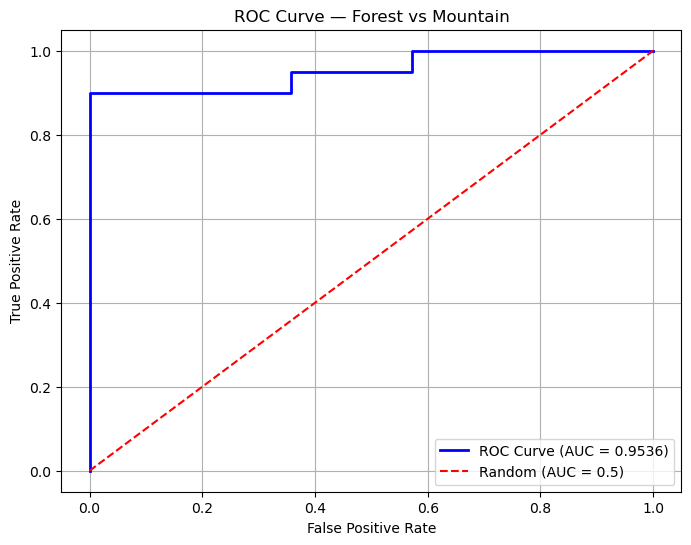

AUC Score: 0.9536


In [21]:
y_pred_prob = model_binary.predict(X_bin_test).flatten()

fpr, tpr, _ = roc_curve(y_bin_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Forest vs Mountain')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")